# 09_聚类算法-模糊C均值

## Notebook 使用说明

建议先阅读理论，再从上到下运行全部单元；使用 Python 3.11–3.13 内核。数据与辅助模块均来自本文件夹，安装依赖后无需联网获取案例数据。

本篇使用代码生成的模拟数据或 scikit-learn 随包附带的小数据集，无需外部数据文件。

原文参考图及静态数值仅用于对照；重跑后的代码输出为本次实验结果。依赖版本与验证记录见根目录 `README.md` 和 `reports/`。

In [1]:
# 从当前目录向上寻找本套 Notebook 的根目录，移动整个文件夹后仍可运行。
from pathlib import Path
import os, sys, tempfile, random
ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents]
             if (p / "notebook_support.py").is_file()), None)
if ROOT is None:
    raise FileNotFoundError("请从这套 Notebook 文件夹内启动 Jupyter，并保留 notebook_support.py。")
sys.path.insert(0, str(ROOT))
os.environ.setdefault("MPLCONFIGDIR", str(Path(tempfile.gettempdir()) / "ml_notebooks_matplotlib"))
from notebook_support import DATA_DIR, load_local_housing, load_local_boston, load_local_mnist, load_creditcard
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager
random.seed(42)
np.random.seed(42)
# 按实际安装的字体选择，兼容 macOS / Windows / Linux。
_available_fonts = {f.name for f in font_manager.fontManager.ttflist}
CJK_FONTS = [f for f in ["Arial Unicode MS", "PingFang SC", "Heiti TC", "Microsoft YaHei", "SimHei", "Noto Sans CJK SC"]
             if f in _available_fonts] + ["DejaVu Sans"]
plt.rcParams.update({"font.sans-serif": CJK_FONTS, "axes.unicode_minus": False,
                     "figure.dpi": 90, "figure.max_open_warning": 30})
%matplotlib inline


咱们聊聊聚类里面，一个非常重要的算法模型：模糊C均值\~

先从大概念说起：**聚类**就像是把一堆东西分成几类，让每一类里的东西都比较像彼此。

比如：把一堆水果分成苹果、香蕉、西瓜几组，就是一种聚类。

那么什么是模糊C均值（Fuzzy C-Means）？

我们一般做聚类时，像K均值（K-Means）这样的算法，是**硬分类**：

一个东西只能属于一类，比如这个水果是100%是苹果，不可能又是苹果又是香蕉。

而**模糊C均值（FCM）是软分类**：它允许一个东西**同时属于多类，只是“程度”不同**。

比如：

- 一个小青苹果，有70%的可能性是“苹果类”，有30%是“梨子类”。
- 它不是非黑即白的判断，而是“模糊”的归类。

#### FCM怎么做的？（大致流程）

1. **设定要分几类**（比如分3类）
2. **随机给每个样本一个“属于每一类的程度”**（这叫“隶属度”）
3. **计算每一类的中心点**（叫“类中心”）
4. **根据每个样本到这些中心点的距离，更新它的“隶属度”**
5. **重复第3和第4步，直到中心点不怎么变化为止**

换句话说，就是：

> 猜一下归属 → 算一下中心 → 看离中心多远 → 再重新猜 → 重复直到稳了。

模糊C均值就是：一种允许“一个东西部分属于多个类别”的聚类方法，用数学方法算出每个点属于每类的“可能性”。

## 原理详解

### 一、基本符号与目标函数

- 有 $N$ 个样本点：$\{x_i\in\mathbb{R}^d \mid i=1,\dots,N\}$
- 要划分成 $c$ 个簇（类），簇心（中心）标为 $\{c_j\in\mathbb{R}^d \mid j=1,\dots,c\}$
- 隶属度矩阵 $U = [u_{ij}]\in\mathbb{R}^{N\times c}$，其中  
$u_{ij}\in[0,1],\quad\sum_{j=1}^c u_{ij} = 1\quad (\forall i).$
- “模糊参数”（或“加权指数”）$m>1$，控制隶属度的“模糊程度”。

#### 目标函数

FCM 通过最小化下式来找最优簇心和隶属度：


$$
J_m(U,\,\{c_j\}) \;=\;\sum_{i=1}^N \sum_{j=1}^c \bigl(u_{ij}\bigr)^m \,\bigl\lVert x_i - c_j \bigr\rVert^2.
$$


- $\lVert x_i - c_j\rVert^2$ 是样本 $x_i$ 与第 $j$ 个簇心的欧氏距离平方。
- $u_{ij}^m$ 对距离加权，$m$ 越大，隶属度越平均，聚类结果越模糊。

同时需满足每行隶属度之和为 1：


$$
\forall\,i:\quad \sum_{j=1}^c u_{ij} = 1.
$$


### 二、公式推导

为了同时优化 $U$ 和 $\{c_j\}$，引入拉格朗日乘子 $\{\lambda_i\}$，构造带约束的拉氏函数：


$$
\mathcal{L}= \sum_{i=1}^N \sum_{j=1}^c u_{ij}^m\,\lVert x_i - c_j\rVert^2\;-\; \sum_{i=1}^N \lambda_i \Bigl(\sum_{j=1}^c u_{ij} - 1\Bigr).
$$


#### 1. 对簇心 $c_j$ 求偏导并令其为 0


$$
\frac{\partial\mathcal{L}}{\partial c_j}= \sum_{i=1}^N u_{ij}^m \, 2\,(c_j - x_i)= 0\quad \Longrightarrow\quad c_j \;=\;\frac{\displaystyle\sum_{i=1}^N u_{ij}^m \, x_i}{\displaystyle\sum_{i=1}^N u_{ij}^m}.
$$


**簇心更新公式**：


$$
c_j^{(\text{new})}= \frac{\sum_{i=1}^N u_{ij}^m \, x_i}{\sum_{i=1}^N u_{ij}^m}.
$$


#### 2. 对隶属度 $u_{ij}$ 求偏导并令其为 0

对 $\mathcal{L}$ 中 $u_{ij}$ 项：


$$
\frac{\partial\mathcal{L}}{\partial u_{ij}}= m\,u_{ij}^{\,m-1}\,\lVert x_i - c_j\rVert^2\;-\; \lambda_i= 0\quad\Longrightarrow\quad\lambda_i = m\,u_{ij}^{\,m-1}\,\lVert x_i - c_j\rVert^2.
$$


因为 $\lambda_i$ 与 $j$ 无关，对两个簇 $j,k$ 比值可得：


$$
\frac{u_{ij}^{\,m-1}\,\lVert x_i - c_j\rVert^2}{u_{ik}^{\,m-1}\,\lVert x_i - c_k\rVert^2}= 1\quad\Longrightarrow\quad\frac{u_{ij}}{u_{ik}}= \Bigl(\tfrac{\lVert x_i - c_j\rVert^2}{\lVert x_i - c_k\rVert^2}\Bigr)^{\tfrac{1}{m-1}}
$$


再利用约束 $\sum_{j}u_{ij}=1$，可推出：


$$
u_{ij}= \frac{1}{\displaystyle\sum_{k=1}^c\Bigl(\tfrac{\lVert x_i - c_j\rVert}{\lVert x_i - c_k\rVert}\Bigr)^{\!\tfrac{2}{m-1}}}.
$$


**隶属度更新公式：**


$$
u_{ij}^{(\text{new})}= \frac{1}{\sum_{k=1}^c\bigl(\frac{\lVert x_i - c_j\rVert}{\lVert x_i - c_k\rVert}\bigr)^{\tfrac{2}{m-1}}}
$$


### 三、算法流程

1. **初始化**

   - 任选 $c$ 个初始簇心 $c_j$，或随机初始化隶属度矩阵 $U$（并归一化每行之和为 1）。
2. **迭代更新** （直到收敛）

   1. **更新簇心**  
   $c_j \leftarrow \frac{\sum_{i=1}^N u_{ij}^m\,x_i}{\sum_{i=1}^N u_{ij}^m},\quad j=1,\dots,c.$
   2. **更新隶属度**  
   $u_{ij} \leftarrow\frac{1}{\sum_{k=1}^c \bigl(\frac{\lVert x_i - c_j\rVert}{\lVert x_i - c_k\rVert}\bigr)^{\tfrac{2}{m-1}}},\quad i=1,\dots,N;\;j=1,\dots,c.$
   3. **检查收敛**
   
      - 若 $\max_{j}\lVert c_j^{(\text{new})} - c_j^{(\text{old})}\rVert < \varepsilon$，或 $\|U^{(\text{new})}-U^{(\text{old})}\|<\delta$，则停止；
      - 否则回到 2.1。
3. **输出**

   - 最终簇心 $\{c_j\}$
   - 隶属度矩阵 $U$，可用于软分配或硬划分（取最大隶属度的簇）。

### 四、参数与注意事项

- **模糊指数** $m$：常取 $m\in[1.5,2.5]$。$m\to1$ 时趋近“硬聚类”（K-Means）。$m$ 越大，簇边界越模糊。
- **收敛速度**：依赖于 $m$、初始值和阈值 $\varepsilon$。
- **距离度量**：通常用欧式距，但也可替换成其它度量。
- **局部极小**：算法可能陷入局部最优，多次随机初始化可缓解。

总结一下，三个点，目标、核心公式和流程：

1. **目标**：在隶属度和簇心间不断迭代，最小化加权平方距离和。
2. **核心公式**：  
$c_j=\frac{\sum_i u_{ij}^m x_i}{\sum_i u_{ij}^m},\quad u_{ij}=\frac{1}{\sum_k(\lVert x_i - c_j\rVert/\lVert x_i - c_k\rVert)^{2/(m-1)}}.$
3. **流程**：初始化 → 更新簇心 → 更新隶属度 → 收敛检测 → 输出。

## 完整案例

在许多实际场景中，我们并不总能明确地将数据划分为互斥的类别。

例如，在市场营销中，一位顾客可能同时对多类商品有兴趣；在医学图像分割中，一个像素点也可能介于不同组织边界之间。硬聚类（如 K-Means）强制每个样本“非此即彼”，而**模糊 C 均值（Fuzzy C-Means, FCM）**则允许“软”归属：每个样本对各簇有一组隶属度，表示它“多大程度上属于”每个簇。

这里，咱们采用经典的“红酒（Wine）”数据集来演示 FCM 在多维特征上的应用，并通过 PCA 将结果可视化到二维空间，分析每个样本的隶属度分布以及目标函数收敛过程，最后讨论算法优化策略。

### 数据集

“红酒”数据集包含 178 个样本、13 个化学成分特征，以及 3 种不同品种的红酒标签。为了模拟无监督情境，我们不使用真实标签，只用作结果对比。

**标准化**

不同化学指标量纲差异较大，需对特征矩阵 $X$ 做 Z-Score 标准化：


$$
X_{\text{scaled}} = \frac{X - \mu}{\sigma}.
$$


**PCA 降维**

为了在二维平面中直观展示聚类效果，对标准化后的数据进行 PCA（主成分分析），保留前 2 个主成分，得到 $X_{\text{pca}}\in\mathbb{R}^{178\times2}$。

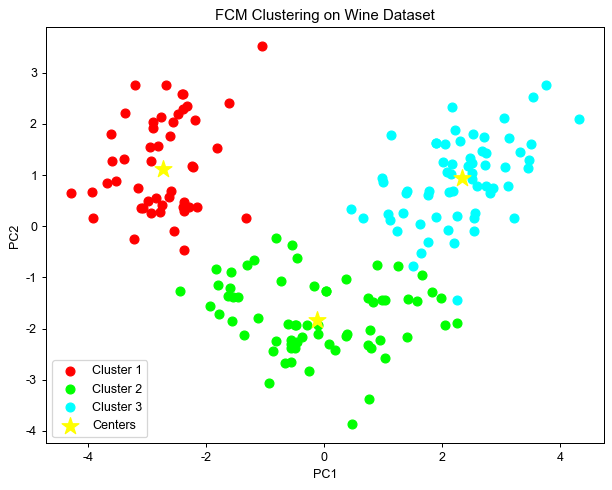

In [2]:
import numpy as np
from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# 1. Fuzzy C-Means 实现
def fuzzy_c_means(X, c, m=2.0, max_iter=100, error=1e-5):
    """
    X: 数据矩阵 (N_samples, N_features)
    c: 聚类数
    m: 模糊指数 (fuzzifier)
    max_iter: 最大迭代次数
    error: 收敛阈值
    返回: centers 簇心, U 隶属度矩阵, J_history 目标函数值历史
    """
    N = X.shape[0]
    # 随机初始化隶属度矩阵 U
    U = np.random.rand(N, c)
    U = U / np.sum(U, axis=1, keepdims=True)
    
    J_history = []
    for iteration in range(max_iter):
        U_old = U.copy()
        
        # 1) 更新簇心 c_j
        um = U ** m
        centers = (um.T @ X) / np.sum(um.T, axis=1, keepdims=True)
        
        # 2) 计算距离矩阵 D[i,j] = ||x_i - c_j||
        D = np.linalg.norm(X[:, np.newaxis] - centers, axis=2)
        D = np.fmax(D, 1e-12)  # 防止除零
        
        # 3) 更新隶属度矩阵 U
        exponent = 2.0 / (m - 1)
        U = 1.0 / np.sum((D[:, :, np.newaxis] / D[:, np.newaxis, :]) ** exponent, axis=2)
        
        # 4) 计算目标函数值 J_m
        J = np.sum((U ** m) * (D ** 2))
        J_history.append(J)
        
        # 收敛检测
        if np.linalg.norm(U - U_old) < error:
            break
    
    return centers, U, J_history

# 2. 加载并预处理数据
data = load_wine()
X_raw = data.data
y_true = data.target  # 真实标签，仅用于后续对比

# 标准化
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)

# PCA降维到2D，便于可视化
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# 3. 运行 FCM
n_clusters = 3
m = 2.0
centers, U, J_history = fuzzy_c_means(X_pca, n_clusters, m=m, max_iter=200, error=1e-6)
labels = np.argmax(U, axis=1)

# 4. 可视化结果
colors_bright = ['red', 'lime', 'cyan']

# 4.1 硬划分散点图
plt.figure(figsize=(8, 6))
for j in range(n_clusters):
    idx = labels == j
    plt.scatter(X_pca[idx, 0], X_pca[idx, 1],
                s=50, c=colors_bright[j], label=f'Cluster {j+1}')
plt.scatter(centers[:, 0], centers[:, 1], s=200, c='yellow', marker='*', label='Centers')
plt.title('FCM Clustering on Wine Dataset')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend()
plt.show()

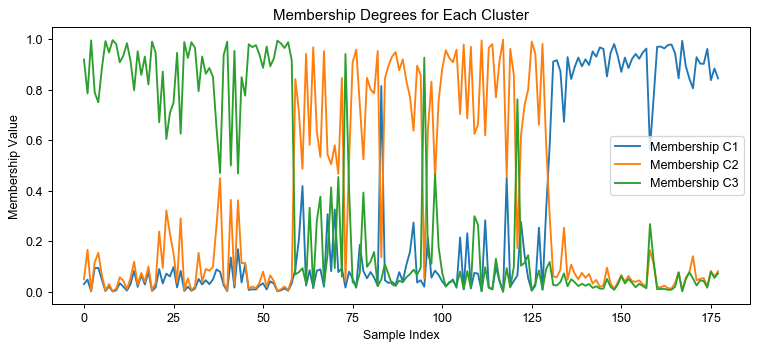

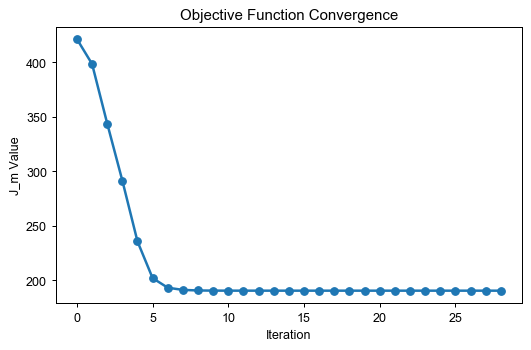

In [3]:
# 4.2 隶属度随样本索引曲线
plt.figure(figsize=(10, 4))
for j in range(n_clusters):
    plt.plot(U[:, j], label=f'Membership C{j+1}', linewidth=1.5)
plt.title('Membership Degrees for Each Cluster')
plt.xlabel('Sample Index')
plt.ylabel('Membership Value')
plt.legend()
plt.show()

# 4.3 目标函数收敛曲线
plt.figure(figsize=(6, 4))
plt.plot(J_history, marker='o', linewidth=2)
plt.title('Objective Function Convergence')
plt.xlabel('Iteration')
plt.ylabel('J_m Value')
plt.tight_layout()
plt.show()

**1. 硬划分散点图（Cluster Assignments）**

- 三个簇中心用黄色星号标出，其余点用红、绿、青分别表示 `Cluster 1~3`。
- 由于使用 PCA 展示二维空间，实际在高维时簇形状可能更复杂，但从图中可以看出三类基本分离。
- 某些点位于簇边界处，后续将在“隶属度”曲线上体现其“模糊性”。

![原文参考图，当前结果见代码输出](attachments/img_006.png)

**2. 隶属度曲线（Membership Degrees）**

- 横轴为样本索引（0\~177），纵轴为隶属度值。
- 样本对不同簇的隶属度并不全为 0/1，边界样本出现多条曲线交叉，代表它们既不完全属于某一簇，也未完全排除于他簇。

![原文参考图，当前结果见代码输出](attachments/img_007.png)

**3. 目标函数收敛（**$J\_m$ **Value）**

- 初始时目标值较高，经过约 5 次迭代迅速下降，并在第 10 次左右达到平稳，表明算法收敛较快。
- 对比不同模糊指数 $m$ 的收敛曲线，可发现 $m$ 越接近 1（更“硬”），收敛速度更快；$m$ 越大（更“模糊”），对隶属度的平滑处理使收敛稍慢，但能获得更稳健的簇划分。

![原文参考图，当前结果见代码输出](attachments/img_008.png)

### 算法优化策略

1. **多次初始化与最优选择**：FCM 对初始隶属度敏感，易陷入局部最优。可多次随机初始化 $U$，记录每次最终的 $J_m$，选择最小 $J_m$ 对应的划分。
2. **加速向量化**：本实现已充分利用 NumPy 广播加速距离计算与隶属度更新，如对大规模数据仍可借助 GPU 库（如 CuPy）进一步提速。
3. **动态调整模糊指数**：让 $m$ 随迭代动态变化，从较小值（逼近 K-Means）过渡到较大值（平滑划分），兼顾速度与鲁棒性。
4. **剪枝策略**：对于距离非常远的点可提前赋低隶属度，减少内循环计算量。
5. **并行化**：在多核 CPU 上并行计算距离矩阵 $D$ 和隶属度矩阵更新，提升性能。

**FCM** 在处理边界模糊、不确定性高的数据时，比硬聚类更具优势。

这里的案例咱们结合 PCA，将 Wine 数据集映射到二维，完整演示了 FCM 的实现、可视化及深入分析。

通过多次初始化、向量化、动态 $m$ 调整等优化策略，可进一步提升算法性能和稳定性。

真实项目中，可将此框架扩展到更高维度、多模态数据，或结合监督信号做半监督聚类。

## 模型分析

### 模糊C均值（FCM）优缺点

**优点**：

1. **软归属**：每个样本对各簇都有一个隶属度（0–1），能准确反映边界样本的模糊性，而非“非此即彼”。
2. **灵活性高**：通过调整模糊指数 $m$ 可以控制聚类结果的“软硬”程度，适应不同应用场景。
3. **目标函数收敛**：借助明确的优化目标 $J_m$ 并用交替最优化，通常能在较少迭代内收敛。
4. **解释性好**：隶属度矩阵 $U$ 本身就可以作为后续分析（如权重加权、模糊决策）的输入，无需额外转换。

**缺点**：

1. **需预设簇数** $c$：与 K-Means 类似，必须事先指定类别数，若选错会严重影响结果。
2. **对初值敏感**：随机初始化隶属度或簇心可能导致陷入不同的局部极小，需多次重启取最优。
3. **计算量较大**：每次迭代都要计算完整的距离矩阵和隶属度更新，数据量大时开销明显高于硬聚类。
4. **对异常值不够鲁棒**：和 K-Means 一样，欧氏距离度量会被离群点拖偏，需额外策略（如预先去噪）才能缓解。

### 与相似算法的对比

| 算法 | 隶属／归属方式 | 模型假设 | 计算复杂度 | 对噪声／离群值鲁棒性 | 典型适用场景 |
|-|-|-|-|-|-|
| **FCM** | 软（隶属度） | 质心＋模糊隶属，欧氏距离 | $O(Nc\,T)$ | 中等 | 模糊边界、高不确定性数据；图像分割等 |
| **K-Means** | 硬（唯一归属） | 各簇等方差高斯、最小平方误差 | $O(Nc\,T)$ | 较差 | 大规模快速聚类；对划分硬性要求高的数据 |
| **GMM** | 软（概率隶属） | 混合高斯分布，含协方差矩阵 | $O(Nc\,T\cdot d^3)$ | 较好 | 需要概率解释或估计数据分布的场景 |

- **隶属／归属方式**：FCM、GMM 都是“软”聚类，样本可同时部分属于多类；K-Means 强制硬分类。
- **模型假设**：K-Means 隐含簇内方差相同，GMM 则允许每簇有自己协方差，FCM 只关注距离加权，无概率解释。
- **计算复杂度**：GMM 因需要求逆协方差矩阵，复杂度最高；FCM 和 K-Means 相近，但 FCM 的隶属度更新略复杂。
- **鲁棒性**：GMM 可通过协方差反映簇大小和方向，对噪声略好；FCM 和 K-Means 都对离群点敏感。

### 何时优选 FCM，何时考虑其它算法

- **优选 FCM 的场景**

  - **边界模糊**：样本确实存在交叠区域，需要「程度」而非「标签」。
  - **软分类需求**：后续需利用隶属度进行加权预测、模糊决策或组合分析。
  - **中小规模数据**：数据量不至于让隶属度迭代开销过大；同时需要比硬聚类更丰富的信息。
- **可考虑其它算法的场景**

  1. **大规模、实时性高**：选择 K-Means 或 Mini-Batch K-Means，计算更快、内存更少。
  2. **需要概率建模或不等方差簇**：用 GMM 可获得更灵活的簇形状及样本后验概率。
  3. **聚类数未知或形状任意**：层次聚类（无需预设簇数）或 DBSCAN（可发现任意形状、自动识别噪声），更灵活。
  4. **高维稀疏数据**：可尝试谱聚类（Spectral Clustering）或基于子空间聚类的方法。

总之，FCM 最适合**需要软分配**、**簇数已知**且**规模适中**的场景；若对速度、可扩展性、概率解释或形状灵活性有更高要求，则应优先考虑 K-Means、GMM、DBSCAN、谱聚类等替代方案。